# 🇮🇳 NSE Swing Trading — Rule-Based Scoring Engine

**Approach:** No ML model. Features are weighted into a composite score (0–100).
Top 3 stocks per week are selected. Win rate is validated on the same historical timeframe.

| Parameter | Value |
|-----------|-------|
| Universe  | All NSE Equity Symbols |
| Timeframe | Weekly (1W) |
| Data      | Jan 2024 → Today |
| Output    | Top 3 pre-breakout picks + win rate on same data |

---

## Step 1 — Imports & Global Config

In [77]:
import os, warnings, time
import requests
from io import StringIO
from datetime import datetime
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import yfinance as yf
import ta

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Interval ──────────────────────────────────────────────────────
INTERVAL  = '1d'   # '1wk' or '1d'
BAR_LABEL = 'week' if INTERVAL == '1wk' else 'day'

# ── Dates (fixed — not auto-computed) ────────────────────────────
DATA_START     = '2023-01-01'   # warmup history start
BACKTEST_START = '2024-01-01'   # first signal date

# ── Scan frequency (daily mode only) ─────────────────────────────
SCAN_EVERY = 1   # score every Nth bar; 1 = every bar (slow)

# ── Trade exit rules ──────────────────────────────────────────────
TARGET_PCT    = 10.0   # exit when bar HIGH >= entry × 1.10
STOPLOSS_PCT  =  5.0   # exit when bar LOW  <= entry × 0.93
MAX_HOLD_BARS =  2    # force-close after N bars if neither hit

# ── Signal filters (win-rate improvements) ───────────────────────
MIN_SCORE      = 60    # only take signals scoring >= this (0 = off)
NIFTY_FILTER   = False  # skip signals when Nifty 50 is below its EMA
NIFTY_EMA_SPAN = 10    # EMA span (bars) for Nifty trend filter
MANDATORY_COND = {
    'ret_26w'  : lambda v: v > 0,    # 6m uptrend (works correctly on weekly)
    'rsi_zone' : lambda v: v >= 2,   # RSI 50-70
    'adx'      : lambda v: v >= 15,  # minimum trend — trendless stocks excluded
}

# ── Market cap filter ────────────────────────────────────────────
MIN_MCAP_CR = 500      # minimum market cap in Crores  (500 Cr ~ small cap floor)
MAX_MCAP_CR = 100_000  # maximum market cap in Crores  (1L Cr ~ large cap ceiling)
MCAP_CACHE    = 'mcap_cache.csv'   # saved to disk so re-runs skip re-fetching
MCAP_THREADS  = 50                 # parallel HTTP threads for mcap fetch

# ── Portfolio ─────────────────────────────────────────────────────
TOP_N  = 3
N_JOBS = -1    # -1 = all cores, 1 = serial

SUFFIX     = '.NS'
SIGNAL_CSV = 'nse_top3_signals.csv'
TODAY      = datetime.today().strftime('%Y-%m-%d')

print(f'Interval      : {INTERVAL}  ({BAR_LABEL}ly bars)')
print(f'Data start    : {DATA_START}  (warmup)')
print(f'Backtest start: {BACKTEST_START}')
print(f'Target        : +{TARGET_PCT}%  |  Stop: -{STOPLOSS_PCT}%  |  Max: {MAX_HOLD_BARS} {BAR_LABEL}s')
print(f'Min score     : {MIN_SCORE}  |  Nifty filter: {NIFTY_FILTER}')
print(f'Mandatory     : {list(MANDATORY_COND.keys())}')
print(f'Top N picks   : {TOP_N}')
print(f'MCap range    : Rs {MIN_MCAP_CR:,} Cr  ')


Interval      : 1d  (dayly bars)
Data start    : 2023-01-01  (warmup)
Backtest start: 2024-01-01
Target        : +10.0%  |  Stop: -5.0%  |  Max: 2 days
Min score     : 60  |  Nifty filter: False
Mandatory     : ['ret_26w', 'rsi_zone', 'adx']
Top N picks   : 3
MCap range    : Rs 500 Cr  


## Step 2 — Scrape All NSE Equity Symbols

In [40]:
def fetch_nse_symbols():
    url = 'https://nsearchives.nseindia.com/content/equities/EQUITY_L.csv'
    headers = {'User-Agent': 'Mozilla/5.0', 'Referer': 'https://www.nseindia.com'}
    try:
        s = requests.Session()
        s.get('https://www.nseindia.com', headers=headers, timeout=10)
        r = s.get(url, headers=headers, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(StringIO(r.text))
        col = [c for c in df.columns if 'SYMBOL' in c.upper()][0]
        syms = df[col].dropna().str.strip().tolist()
        print(f'NSE live: {len(syms)} symbols')
        return syms
    except Exception as e:
        print(f'Live fetch failed ({e}) -> curated fallback')

ALL_SYMBOLS = fetch_nse_symbols()
print(f'Total: {len(ALL_SYMBOLS)} symbols')

NSE live: 2251 symbols
Total: 2251 symbols


## Step 3 — Download Weekly OHLCV

In [41]:
def download_ohlcv(symbols, start='2023-01-01', end=TODAY,
                   interval='1d', suffix='.NS', batch=50):
    result, failed = {}, []
    tickers = [s + suffix for s in symbols]
    for i in tqdm(range(0, len(tickers), batch), desc='OHLCV'):
        grp = tickers[i:i+batch]
        try:
            raw = yf.download(
                grp, start=start, end=end, interval=interval,
                group_by='ticker', auto_adjust=True,
                progress=False, threads=True
            )
            for t in grp:
                sym = t.replace(suffix, '')
                try:
                    df = raw[t].copy() if len(grp) > 1 else raw.copy()
                    df.dropna(subset=['Close'], inplace=True)
                    if len(df) >= 52:
                        df.columns = [c.lower() for c in df.columns]
                        result[sym] = df
                    else:
                        failed.append(sym)
                except Exception:
                    failed.append(sym)
        except Exception as e:
            print(f'Batch error: {e}')
        time.sleep(0.3)
    print(f'Downloaded: {len(result)} | Skipped: {len(failed)}')
    return result

print('Downloading weekly OHLCV (may take a few minutes)...')
ohlcv_data = download_ohlcv(ALL_SYMBOLS)
print(f'Universe: {len(ohlcv_data)} stocks')



OHLCV:   0%|          | 0/46 [00:00<?, ?it/s]

Downloaded: 2216 | Skipped: 35
Universe: 2216 stocks


## Step 3b — Market Cap Filter

Removes symbols outside `MIN_MCAP_CR` to `MAX_MCAP_CR` range. Results are cached to `mcap_cache.csv` so re-runs skip re-fetching.

In [42]:
# ══════════════════════════════════════════════════════════════════
# Market Cap Filter — parallel fetch via ThreadPoolExecutor
#
# Each yf.Ticker().fast_info call is a separate HTTP request.
# Running them sequentially = 2000 symbols × ~0.3s = 10 minutes.
# Running with 50 threads = same 2000 symbols in ~15 seconds.
# ══════════════════════════════════════════════════════════════════

from concurrent.futures import ThreadPoolExecutor, as_completed

MCAP_THREADS = 50   # concurrent HTTP connections (safe for yfinance)

def _fetch_one(sym, suffix=SUFFIX):
    """Fetch market cap for a single symbol. Returns (sym, mcap_cr)."""
    try:
        mc = yf.Ticker(sym + suffix).fast_info.market_cap
        return sym, round(mc / 1e7, 2) if mc else None
    except Exception:
        return sym, None


def fetch_mcap(symbols, suffix=SUFFIX, cache_path=MCAP_CACHE,
               n_threads=MCAP_THREADS):
    """
    Fetches market cap (Crores) for all symbols in parallel.
    Loads existing cache from disk — only fetches symbols not yet cached.
    Saves updated cache after each run.
    """
    # Load existing cache
    if os.path.exists(cache_path):
        _df       = pd.read_csv(cache_path, index_col=0)
        mcap_dict = _df['mcap_cr'].to_dict()
        print(f'Loaded {len(mcap_dict)} cached entries from {cache_path}')
    else:
        mcap_dict = {}

    # Only fetch symbols not in cache
    missing = [s for s in symbols if s not in mcap_dict]

    if not missing:
        print('All symbols already cached. Skipping fetch.')
        return mcap_dict

    print(f'Fetching mcap for {len(missing)} symbols '
          f'({n_threads} threads)...')

    t0       = time.time()
    done     = 0
    failed   = 0

    with ThreadPoolExecutor(max_workers=n_threads) as pool:
        futures = {pool.submit(_fetch_one, sym, suffix): sym
                   for sym in missing}

        for future in tqdm(as_completed(futures),
                           total=len(futures), desc='MCap fetch'):
            sym, mc = future.result()
            mcap_dict[sym] = mc
            done += 1
            if mc is None:
                failed += 1

    elapsed = time.time() - t0
    rate    = len(missing) / elapsed if elapsed > 0 else 0
    print(f'Fetched {len(missing)} symbols in {elapsed:.1f}s  '
          f'({rate:.0f} symbols/sec)  |  '
          f'{failed} returned None')

    # Save updated cache
    pd.DataFrame.from_dict(
        mcap_dict, orient='index', columns=['mcap_cr']
    ).to_csv(cache_path)
    print(f'Cache saved -> {cache_path}  ({len(mcap_dict)} total entries)')

    return mcap_dict


# Fetch / load
mcap_cache = fetch_mcap(list(ohlcv_data.keys()))

# Apply filter
before     = len(ohlcv_data)
ohlcv_data = {
    sym: df
    for sym, df in ohlcv_data.items()
    if mcap_cache.get(sym) is not None
    and MIN_MCAP_CR <= mcap_cache[sym] 
}
after = len(ohlcv_data)

print()
print(f'Market cap filter : Rs {MIN_MCAP_CR:,} Cr  ->  Rs {MAX_MCAP_CR:,} Cr')
print(f'Before            : {before} symbols')
print(f'Removed           : {before - after}  (no mcap data or out of range)')
print(f'After             : {after} symbols')
print()

# Distribution of remaining universe
mcap_series = pd.Series({s: mcap_cache[s] for s in ohlcv_data
                          if mcap_cache.get(s) is not None})
bins   = [0, 500, 2_000, 10_000, 50_000, 100_000, float('inf')]
labels = ['<500 Cr','500-2k','2k-10k','10k-50k','50k-1L Cr','>1L Cr']
dist   = pd.cut(mcap_series, bins=bins, labels=labels).value_counts().sort_index()
print('  MCap distribution:')
for band, count in dist.items():
    bar = chr(9608) * int(count / max(dist.values) * 30)
    print(f'  {band:12s}  {count:5d}  {bar}')


Loaded 2216 cached entries from mcap_cache.csv
All symbols already cached. Skipping fetch.

Market cap filter : Rs 500 Cr  ->  Rs 100,000 Cr
Before            : 2216 symbols
Removed           : 1587  (no mcap data or out of range)
After             : 629 symbols

  MCap distribution:
  <500 Cr           0  
  500-2k          200  ██████████████████████████
  2k-10k          227  ██████████████████████████████
  10k-50k         131  █████████████████
  50k-1L Cr        30  ███
  >1L Cr           41  █████


## Step 4 — OBV Accumulation Proxy (replaces Institutional API)

The NSE institutional APIs (delivery %, block deals, FII/DII) require session cookies
and frequently return 403/404 errors in automated notebooks.

**Replacement — OBV-based smart-money proxy (100% reliable, no external API):**

| Feature | Logic | Why it works |
|---------|-------|--------------|
| `obv_rising` | OBV today > OBV 4 weeks ago | Volume-weighted price trend — institutions can't hide accumulation in OBV |
| `obv_slope_z` | Z-score of OBV slope over 10 weeks | Normalised accumulation rate — rising Z = accelerating buying |
| `vol_price_confirm` | High volume AND price above EMA20 | Smart money buys on strength, not weakness |

These are computed inside `compute_features()` below using only yfinance OHLCV data — no external API needed.

In [43]:
# OBV proxy — computed inside compute_features(), nothing to fetch here.
# This cell is intentionally minimal; all logic lives in Step 5.
print('OBV accumulation proxy will be computed per-symbol in Step 5.')

OBV accumulation proxy will be computed per-symbol in Step 5.


## Step 5 — Feature Engineering (Top-6 + OBV Accumulation Proxy)

In [55]:
# ── Feature set used for scoring ─────────────────────────────────
FEATURE_COLS = [
    'stoch_momentum',    # gradient: stoch_k peak at 55, triangle 20→80
    'rsi_zone',          # gradient: 0→0, 1→0.25, 2→1.0, 3→0.4  (keep as-is)
    'vol_momentum',      # gradient: vol_ratio × up-bar factor, 0.8x→3.0x
    'squeeze_intensity', # gradient: ATR contraction degree, max at 50% compression
    'trend_strength',    # gradient: ADX 10→40  (NEW)
    'obv_slope_z',       # gradient: OBV slope z-score  (keep as-is)
    'upside_room',       # gradient: distance from resistance, peak at 12%  (NEW)
    'ema_strength',      # gradient: above EMA20 but not extended
    'ret_26w',           # gradient: 6m return 0→50%  (keep as-is)
    'macd_strength',     # gradient: MACD hist z-score  (NEW)
    'ret_2w',            # gradient: 2-bar return  (keep as-is)
]

def compute_features(df):
    d   = df.copy()
    c, h, l, o, v = d['close'], d['high'], d['low'], d['open'], d['volume']

    # ── Stochastic: gradient over bull zone ──────────────────────────
    st = ta.momentum.StochasticOscillator(h, l, c, window=14, smooth_window=3)
    d['stoch_k']         = st.stoch()
    d['stoch_d']         = st.stoch_signal()
    d['stoch_cross_up']  = ((d['stoch_k'] > d['stoch_d']) &
                             (d['stoch_k'].shift(1) <= d['stoch_d'].shift(1))).astype(int)
    sk = d['stoch_k']
    # Triangle peak at K=55: zero at 20 and 80
    d['stoch_momentum']  = np.clip(np.minimum((sk - 20) / 35, (80 - sk) / 25), 0, 1)

    # ── RSI zone (keep existing — already gradient) ───────────────────
    d['rsi_14']  = ta.momentum.rsi(c, window=14)
    d['rsi_zone'] = pd.cut(d['rsi_14'], bins=[0,30,50,70,100],
                            labels=[0,1,2,3]).astype(float)

    # ── Returns (keep existing — already gradient) ────────────────────
    d['ret_2w']  = c.pct_change(2)  * 100
    d['ret_26w'] = c.pct_change(26) * 100

    # ── Volume: gradient momentum on up-bars ─────────────────────────
    d['vol_ma20']  = v.rolling(20).mean()
    d['vol_ratio'] = v / d['vol_ma20']
    up_bar = (c > c.shift(1)).astype(float)
    # Ramps from 0 at 0.8× to 1.0 at 3.0×; penalised 90% on down-bars
    d['vol_momentum'] = (
        np.clip((d['vol_ratio'] - 0.8) / 2.2, 0, 1) * (up_bar * 0.9 + 0.1)
    ).fillna(0)
    d['vol_surge'] = ((d['vol_ratio'] >= 1.5) & (c > c.shift(1))).astype(int)

    # ── ATR: gradient squeeze intensity ──────────────────────────────
    d['atr_14']   = ta.volatility.average_true_range(h, l, c, window=14)
    d['atr_pct']  = d['atr_14'] / c
    atr_mean      = d['atr_pct'].rolling(10).mean().replace(0, np.nan)
    atr_ratio     = d['atr_pct'] / atr_mean        # 1.0 = normal, <1 = contracted
    # Score: 0 at ratio=1.0, max 1.0 at ratio=0.5 (50% contraction)
    d['squeeze_intensity'] = np.clip(2 * (1 - atr_ratio), 0, 1).fillna(0)
    d['atr_contraction']   = (atr_ratio <= 0.80).astype(int)

    # ── ADX: gradient trend strength (NEW SCORED FEATURE) ────────────
    adx_i          = ta.trend.ADXIndicator(h, l, c, window=14)
    d['adx']       = adx_i.adx()
    d['di_plus']   = adx_i.adx_pos()
    d['di_minus']  = adx_i.adx_neg()
    # Ramps from 0 at ADX=10 to 1.0 at ADX=40; plateaus above 40
    d['trend_strength'] = np.clip((d['adx'] - 15) / 20, 0, 1).fillna(0)

    # ── OBV accumulation (keep existing) ─────────────────────────────
    d['obv']        = ta.volume.on_balance_volume(c, v)
    d['obv_rising'] = (d['obv'] > d['obv'].shift(4)).astype(int)
    obv_chg         = d['obv'].diff(10)
    obv_mean        = obv_chg.rolling(20).mean()
    obv_std         = obv_chg.rolling(20).std().replace(0, np.nan)
    d['obv_slope_z'] = ((obv_chg - obv_mean) / obv_std).clip(-3, 3).fillna(0)

    # ── EMA: gradient "cleanly above but not extended" ───────────────
    d['ema_20'] = ta.trend.ema_indicator(c, window=20)
    d['ema_50'] = ta.trend.ema_indicator(c, window=50)
    ema_dist    = (c - d['ema_20']) / d['ema_20'] * 100  # % above EMA20
    # Triangle: zero at -5% and +12%, peak at +3%
    d['ema_strength'] = np.clip(
        np.minimum((ema_dist + 5) / 8, (12 - ema_dist) / 9), 0, 1
    ).fillna(0)
    d['vol_price_confirm'] = ((d['vol_ratio'] >= 1.2) & (c > d['ema_20'])).astype(int)

    # ── Distance from resistance: gradient upside room (NEW) ─────────
    d['resist_10w']    = h.rolling(10).max()
    d['pct_to_resist'] = (d['resist_10w'] - c) / c * 100   # positive = room to run
    pct = d['pct_to_resist']
    # Triangle: zero at 0% (at resistance) and 40% (too far), peak at 12%
    d['upside_room']     = np.clip(np.minimum(pct / 12, (40 - pct) / 28), 0, 1).fillna(0)
    d['near_resistance'] = (pct <= 3).astype(int)           # kept for compat

    # ── MACD: gradient histogram z-score (NEW SCORED FEATURE) ────────
    macd_i         = ta.trend.MACD(c)
    d['macd_hist'] = macd_i.macd_diff()
    d['macd_cross_up'] = ((d['macd_hist'] > 0) &
                           (d['macd_hist'].shift(1) <= 0)).astype(int)
    hist_std       = d['macd_hist'].rolling(20).std().replace(0, np.nan)
    hist_z         = (d['macd_hist'] / hist_std).clip(-3, 3).fillna(0)
    # Zero at z=−1, max at z=+1 and above
    d['macd_strength'] = np.clip((hist_z + 1) / 2, 0, 1)

    # ── Bollinger squeeze & 52w context (chart use only) ─────────────
    bb = ta.volatility.BollingerBands(c, window=20, window_dev=2)
    d['bb_width']   = (bb.bollinger_hband() - bb.bollinger_lband()) / bb.bollinger_mavg()
    d['bb_squeeze'] = (d['bb_width'] <= d['bb_width'].rolling(20).min() * 1.05).astype(int)
    d['52w_high']           = h.rolling(52).max()
    d['pct_from_52w_high']  = (c - d['52w_high']) / d['52w_high'] * 100

    return d

print('Engineering features...')
feature_dfs = {}
for sym, df in tqdm(ohlcv_data.items(), desc='Features'):
    try:
        fd = compute_features(df)
        fd['symbol'] = sym
        feature_dfs[sym] = fd
    except Exception:
        pass
print(f'Features ready for {len(feature_dfs)} symbols')

Engineering features...


Features:   0%|          | 0/629 [00:00<?, ?it/s]

Features ready for 629 symbols


## Step 6 — Composite Scoring Engine

Each feature contributes a **weighted score**. Weights reflect how reliably each feature predicts a breakout based on trading literature:

| Feature | Weight | Rationale |
|---------|--------|----------|
| `stoch_cross_up` | 20 | Momentum turn — highest predictive binary |
| `vol_surge` | 18 | Volume expansion confirms move |
| `obv_slope_z` | 15 | Continuous accumulation rate — not just on/off |
| `atr_contraction` | 12 | Coiling = energy before breakout |
| `rsi_zone` | 10 | Normalised 0-3 — bull zone scores highest |
| `vol_price_confirm` | 10 | Smart money buying confirmation |
| `ret_26w` | 8 | Strong trend = safer breakout |
| `obv_rising` | 5 | Binary accumulation flag |
| `ret_2w` | 2 | Recent momentum nudge |

In [56]:
# ── Scoring weights ──────────────────────────────────────────────
# Each weight is derived from which features historically correlate
# with winning trades. Adjust after running backtest diagnostics.
WEIGHTS = {
    'stoch_momentum'    : 12,
    'rsi_zone'          : 15,
    'vol_momentum'      : 14,
    'squeeze_intensity' :  7,
    'trend_strength'    : 12,   # ADX
    'obv_slope_z'       : 11,
    'upside_room'       :  8,   # distance from resistance
    'ema_strength'      :  7,
    'ret_26w'           :  8,
    'macd_strength'     :  4,   # MACD hist
    'ret_2w'            :  2,
}
assert sum(WEIGHTS.values()) == 100, 'Weights must sum to 100'



FEAT_ORDER = list(WEIGHTS.keys())          # fixed column order
W_VECTOR   = np.array([WEIGHTS[f] for f in FEAT_ORDER], dtype=float)

print('Weights matrix:')
print(f'  {"Feature":22s}  {"Weight":>6s}  {"% of total":>10s}')
print(f'  {"-"*44}')
for f, w in WEIGHTS.items():
    bar = '█' * int(w / 2)
    print(f'  {f:22s}  {w:6d}  {w:>8.0f}%   {bar}')
print(f'  {"-"*44}')
print(f'  {"TOTAL":22s}  {sum(WEIGHTS.values()):6d}')


# ══════════════════════════════════════════════════════════════════
# build_score_matrix()
#
# Single function that builds ALL matrices needed for both:
#   • today's top-3 picks
#   • the full backtest
#
# How it works:
#   1. Concatenate all symbol DataFrames → one tall DataFrame
#   2. Pivot each feature → (all_dates × symbols) DataFrame
#   3. Reindex to scan_dates + ffill  → last known value per date
#   4. Normalise each feature to [0,1]
#   5. Stack into 3D numpy array  (n_dates × n_symbols × n_features)
#   6. np.einsum dot with W_VECTOR → score matrix (n_dates × n_symbols)
#
# Zero Python loops over symbols or dates.
# ══════════════════════════════════════════════════════════════════
def build_score_matrix(feature_dfs, scan_dates):
    """
    Parameters
    ----------
    feature_dfs : dict  {symbol: DataFrame}
    scan_dates  : list of Timestamps  — dates to score on

    Returns
    -------
    score_df  : DataFrame (scan_dates × symbols)  — composite score 0-100
    close_df  : DataFrame (scan_dates × symbols)  — close price
    norm_df   : dict {feature: DataFrame}          — normalised 0-1 values
    flag_df   : dict {feature: DataFrame}          — raw feature values
    """
    t0       = time.time()
    scan_idx = pd.DatetimeIndex(sorted(scan_dates))

    # ── 1. Concatenate all symbols ────────────────────────────────
    extra_cols = ['close','rsi_14','vol_ratio','adx',
                  'bb_squeeze','near_resistance','macd_cross_up','pct_to_resist']
    keep_cols  = FEAT_ORDER + [c for c in extra_cols if c not in FEAT_ORDER]

    frames = []
    for sym, df in feature_dfs.items():
        cols = [c for c in keep_cols if c in df.columns]
        tmp  = df[cols].copy()
        tmp['_sym'] = sym
        frames.append(tmp)

    tall = pd.concat(frames)
    tall.index.name = 'date'
    tall = tall.reset_index()

    # ── 2. Pivot every column → (date × symbol) ──────────────────
    all_cols = [c for c in keep_cols if c in tall.columns]
    pivot = {}
    for col in all_cols:
        pivot[col] = (
            tall.pivot(index='date', columns='_sym', values=col)
                .sort_index()
        )

    # ── 3. Reindex to scan_dates + forward-fill ───────────────────
    # One vectorised operation replaces all searchsorted() loops
    for col in all_cols:
        pivot[col] = (
            pivot[col]
            .reindex(pivot[col].index.union(scan_idx))
            .ffill()
            .reindex(scan_idx)
        )

    symbols = pivot['close'].columns.tolist()

    # ── 4. Normalise each scoring feature → [0,1] ─────────────────
    norm = {}

    # Pre-normalised in compute_features() — just clip and fill
    for f in ['stoch_momentum', 'vol_momentum', 'squeeze_intensity',
              'trend_strength', 'upside_room', 'ema_strength', 'macd_strength']:
        norm[f] = pivot[f].clip(0, 1).fillna(0)

    # rsi_zone: 0→0.0, 1→0.25, 2→1.0, 3→0.4
    rz_map = {0: 0.0, 1: 0.25, 2: 1.0, 3: 0.4}
    norm['rsi_zone'] = (
        pivot['rsi_zone'].round().clip(0, 3)
        .apply(lambda col: col.map(rz_map))
        .astype(float).fillna(0)
    )

    # obv_slope_z: (−3..+3) → (0..1)
    norm['obv_slope_z'] = (
        (pivot['obv_slope_z'].clip(-3, 3) + 3) / 6
    ).fillna(0)

    # ret_26w: (0..50%) → (0..1)
    norm['ret_26w'] = (
        pivot['ret_26w'].clip(lower=0).div(50).clip(upper=1)
    ).fillna(0)

    # ret_2w: (−5..+5%) → (0..1)
    norm['ret_2w'] = (
        (pivot['ret_2w'].clip(-5, 5) + 5) / 10
    ).fillna(0)
    # obv_slope_z: (-3..+3) → (0..1)
    norm['obv_slope_z'] = (
        (pivot['obv_slope_z'].clip(-3, 3) + 3) / 6
    ).fillna(0)

    # ret_26w: (0..50%) → (0..1)
    norm['ret_26w'] = (
        pivot['ret_26w'].clip(lower=0).div(50).clip(upper=1)
    ).fillna(0)

    # ret_2w: (-5..+5%) → (0..1)
    norm['ret_2w'] = (
        (pivot['ret_2w'].clip(-5, 5) + 5) / 10
    ).fillna(0)

    # ── 5. Stack into 3D array  (n_dates × n_symbols × n_features) ─
    n_dates = len(scan_idx)
    n_syms  = len(symbols)

    feat_array = np.stack(
        [norm[f].reindex(columns=symbols).values for f in FEAT_ORDER],
        axis=2                    # axis-2 = feature dimension
    )                             # shape: (n_dates, n_syms, n_feats)

    # ── 6. Score = einsum dot with weight vector ──────────────────
    # 'dsf,f->ds': for each date d, symbol s: Σ feat[d,s,f] * w[f]
    score_array = np.einsum('dsf,f->ds', feat_array, W_VECTOR)
    score_df    = pd.DataFrame(
        np.round(score_array, 2), index=scan_idx, columns=symbols
    )

    close_df = pivot['close'].reindex(columns=symbols)

    # Raw feature values for reporting
    flag_df  = {f: pivot[f].reindex(columns=symbols) for f in pivot}

    elapsed = time.time() - t0
    print(f'Score matrix built: {score_df.shape[0]} dates × '
          f'{score_df.shape[1]} symbols  in {elapsed:.1f}s')
    return score_df, close_df, norm, flag_df


print()
print('build_score_matrix() ready — pure matrix ops, no Python loops.')


Weights matrix:
  Feature                 Weight  % of total
  --------------------------------------------
  stoch_momentum              12        12%   ██████
  rsi_zone                    15        15%   ███████
  vol_momentum                14        14%   ███████
  squeeze_intensity            7         7%   ███
  trend_strength              12        12%   ██████
  obv_slope_z                 11        11%   █████
  upside_room                  8         8%   ████
  ema_strength                 7         7%   ███
  ret_26w                      8         8%   ████
  macd_strength                4         4%   ██
  ret_2w                       2         2%   █
  --------------------------------------------
  TOTAL                      100

build_score_matrix() ready — pure matrix ops, no Python loops.


## Step 7 — Today's Top 3 Picks

In [57]:
# ── Today's picks via the same matrix path ───────────────────────
# We pass [TODAY] as the single scan date — build_score_matrix
# handles the pivot + ffill + einsum exactly as in the backtest.
# No separate score_row() or score_universe_at_date() call.

print(f'Computing today\'s top {TOP_N} via matrix multiply ({TODAY})...')
print()

today_ts             = pd.Timestamp(TODAY)
score_td, close_td, norm_td, flag_td = build_score_matrix(
    feature_dfs, [today_ts]
)

# ── Score row for today ───────────────────────────────────────────
scores_today = score_td.loc[today_ts].dropna().sort_values(ascending=False)
closes_today = close_td.loc[today_ts]

# ── Apply mandatory conditions ────────────────────────────────────
def passes_mandatory(sym, flag_df_local, mandatory=MANDATORY_COND):
    for feat, cond in mandatory.items():
        val = flag_df_local.get(feat, pd.Series(dtype=float))
        if isinstance(val, pd.DataFrame):
            val = val.loc[today_ts] if today_ts in val.index else pd.Series(dtype=float)
        v = val.get(sym, None)
        if v is None or pd.isna(v) or not cond(float(v)):
            return False, feat
    return True, None

filtered = []
for sym, sc in scores_today.items():
    if sc < MIN_SCORE:
        continue
    ok, failed_feat = passes_mandatory(sym, flag_td)
    if not ok:
        continue
    filtered.append((sym, sc))

top3 = filtered[:TOP_N]

# ── Print weights table ───────────────────────────────────────────
print('=' * 68)
print(f'  APPLIED WEIGHTS')
print(f'  {"Feature":22s}  {"Weight":>6s}  {"Bar":<20s}')
print(f'  {"-"*55}')
for f, w in WEIGHTS.items():
    bar = '█' * int(w / 2)
    print(f'  {f:22s}  {w:6d}  {bar}')
print(f'  {"-"*55}')
print(f'  {"TOTAL":22s}  {sum(WEIGHTS.values()):6d}')
print()

# ── Print top picks ───────────────────────────────────────────────
print('=' * 68)
print(f'  NSE TOP {TOP_N} PICKS  —  {TODAY}')
print(f'  Target +{TARGET_PCT}%  |  Stop -{STOPLOSS_PCT}%  |  Min score {MIN_SCORE}')
print(f'  Mandatory: {list(MANDATORY_COND.keys())}')
print('=' * 68)

if not top3:
    print('  No signals pass all filters today.')
else:
    for rank, (sym, sc) in enumerate(top3, 1):
        cl   = closes_today.get(sym, float('nan'))
        tgt  = round(cl * (1 + TARGET_PCT/100),   2)
        stp  = round(cl * (1 - STOPLOSS_PCT/100),  2)

        # Per-feature contribution for this symbol
        contribs = []
        for f in FEAT_ORDER:
            nv  = norm_td[f].loc[today_ts].get(sym, 0) if today_ts in norm_td[f].index else 0
            raw = flag_td.get(f, pd.DataFrame())
            rv  = raw.loc[today_ts].get(sym, float('nan')) if today_ts in raw.index else float('nan')
            contrib = round(float(nv) * WEIGHTS[f], 1)
            contribs.append((f, WEIGHTS[f], round(float(nv),2), contrib,
                              round(float(rv),2) if not pd.isna(rv) else rv))

        print(f'\n  #{rank}  {sym:12s}  INR {cl:>10,.2f}  Score: {sc:.1f}/100')
        print(f'      Target: {tgt:,.2f}  |  Stop: {stp:,.2f}')
        print(f'      {"Feature":22s}  {"Wt":>4s}  {"Norm":>5s}  {"Pts":>5s}  {"Raw value":<12s}')
        print(f'      {"-"*55}')
        for f, wt, nv, pts, rv in contribs:
            active = '✅' if pts == wt else ('▶' if pts > 0 else '  ')
            print(f'      {active} {f:20s}  {wt:4d}  {nv:5.2f}  {pts:5.1f}  {rv}')
        print(f'      {"-"*55}')
        print(f'      {"TOTAL":22s}        {"":5s}  {sc:5.1f}')

print()
print('  DISCLAIMER: Research only. Not SEBI-registered advice.')
print('=' * 68)

# Save full ranked table
rows = []
for sym, sc in scores_today.items():
    cl = closes_today.get(sym, float('nan'))
    rows.append({'symbol': sym, 'score': sc, 'close': cl,
                 **{f: flag_td[f].loc[today_ts].get(sym, float('nan'))
                    for f in FEAT_ORDER if f in flag_td}})
scored_today = pd.DataFrame(rows).sort_values('score', ascending=False)
scored_today.to_csv(SIGNAL_CSV, index=False)
print(f'Full ranked table → {SIGNAL_CSV}  ({len(scored_today)} symbols)')


Computing today's top 3 via matrix multiply (2026-03-14)...

Score matrix built: 1 dates × 629 symbols  in 12.7s
  APPLIED WEIGHTS
  Feature                 Weight  Bar                 
  -------------------------------------------------------
  stoch_momentum              12  ██████
  rsi_zone                    15  ███████
  vol_momentum                14  ███████
  squeeze_intensity            7  ███
  trend_strength              12  ██████
  obv_slope_z                 11  █████
  upside_room                  8  ████
  ema_strength                 7  ███
  ret_26w                      8  ████
  macd_strength                4  ██
  ret_2w                       2  █
  -------------------------------------------------------
  TOTAL                      100

  NSE TOP 3 PICKS  —  2026-03-14
  Target +10.0%  |  Stop -5.0%  |  Min score 60
  Mandatory: ['ret_26w', 'rsi_zone', 'adx']

  #1  ATGL          INR     565.90  Score: 62.9/100
      Target: 622.49  |  Stop: 537.61
      Feature  

## Step 8 — Win Rate Backtest (Target / Stop-Loss Exit)

For every weekly bar from `BACKTEST_START`:
1. Score all symbols point-in-time → take **top 3**
2. Entry = that week's **close price**
3. Walk forward **week by week** checking:
   - If `HIGH >= entry × 1.10` → **WIN** (target hit)
   - If `LOW  <= entry × 0.93` → **LOSS** (stop hit)
   - If both on the same bar → **conservative: LOSS** (stop assumed hit first)
4. If neither triggers within `MAX_HOLD_BARS` → force-close at that bar's close

> No fixed time horizon — the trade exits **only** when price hits +10% or -7%.

In [ ]:
import multiprocessing, time as _time, os
from joblib import Parallel, delayed
from threading import Lock

N_CORES   = multiprocessing.cpu_count()
N_WORKERS = N_CORES if N_JOBS == -1 else N_JOBS

SYMBOL_BATCH_SIZE = 200
CHECKPOINT_DIR    = 'bt_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Config fingerprint — auto-invalidates checkpoints on any change ──
# Hash of every parameter that affects trade outcomes.
# If you change weights, dates, target, stop, filters — the hash
# changes, old checkpoints are deleted, and the backtest re-runs clean.
import hashlib, json as _json

_config_state = {
    'weights'      : WEIGHTS,
    'target'       : TARGET_PCT,
    'stop'         : STOPLOSS_PCT,
    'max_hold'     : MAX_HOLD_BARS,
    'backtest_start': BACKTEST_START,
    'data_start'   : DATA_START,
    'min_score'    : MIN_SCORE,
    'nifty_filter' : NIFTY_FILTER,
    'nifty_ema'    : NIFTY_EMA_SPAN,
    'mandatory'    : list(MANDATORY_COND.keys()),
    'interval'     : INTERVAL,
    'scan_every'   : SCAN_EVERY,
    'top_n'        : TOP_N,
}
_fingerprint = hashlib.md5(
    _json.dumps(_config_state, sort_keys=True).encode()
).hexdigest()[:12]

_fingerprint_file = os.path.join(CHECKPOINT_DIR, '.config_fingerprint')

# Check if config has changed since last run
_prev_fingerprint = None
if os.path.exists(_fingerprint_file):
    with open(_fingerprint_file) as _f:
        _prev_fingerprint = _f.read().strip()

if _prev_fingerprint != _fingerprint:
    # Config changed — wipe all old checkpoints
    _old_ckpts = [f for f in os.listdir(CHECKPOINT_DIR)
                  if f.startswith('batch_') and f.endswith('.csv')]
    if _old_ckpts:
        print(f'Config changed (hash {_prev_fingerprint} -> {_fingerprint})')
        print(f'Deleting {len(_old_ckpts)} stale checkpoints...')
        for _f in _old_ckpts:
            os.remove(os.path.join(CHECKPOINT_DIR, _f))
        print('Stale checkpoints cleared. Backtest will re-run from scratch.')
    else:
        print(f'New config fingerprint: {_fingerprint}')
    with open(_fingerprint_file, 'w') as _f:
        _f.write(_fingerprint)
else:
    print(f'Config unchanged (fingerprint: {_fingerprint}) — checkpoints valid.')
    print(f'Change any weight/filter/date to trigger a fresh run.')

RESUME = (_prev_fingerprint == _fingerprint)  # only resume if config unchanged

print(f'Workers : {N_WORKERS}  ({N_CORES} cores)')
print(f'Batch sz: {SYMBOL_BATCH_SIZE} symbols')
print(f'Resume  : {RESUME}  (auto-set by config fingerprint)')


# ── Nifty 50 trend filter ─────────────────────────────────────────
# Download once; build a set of bearish dates to skip signals on.
_nifty_bear_dates = set()
if NIFTY_FILTER:
    print('Downloading Nifty 50 for market regime filter...')
    _nf = yf.download('^NSEI', start=DATA_START, end=TODAY,
                      interval=INTERVAL, auto_adjust=True, progress=False)
    if not _nf.empty:
        _nf.columns = [c.lower() if isinstance(c, str) else c[0].lower()
                       for c in _nf.columns]
        _nf_close   = _nf['close'] if 'close' in _nf.columns else _nf.iloc[:,0]
        _nf_ema     = _nf_close.ewm(span=NIFTY_EMA_SPAN, adjust=False).mean()
        _bear       = _nf_close[_nf_close < _nf_ema]
        _nifty_bear_dates = set(_bear.index.normalize())
        print(f'Nifty filter: {len(_nifty_bear_dates)} bear dates will be skipped')
    else:
        print('WARNING: Nifty download failed — filter disabled')


# ── Shared progress (thread-safe) ─────────────────────────────────
_progress_lock    = Lock()
_progress_counter = [0]
_progress_total   = [0]
_progress_start   = [0.0]
_current_batch    = [0]
_total_batches    = [0]

def _report(n=1):
    with _progress_lock:
        _progress_counter[0] += n
        done    = _progress_counter[0]
        total   = _progress_total[0]
        pct     = done / total * 100 if total else 0
        elapsed = _time.time() - _progress_start[0]
        rate    = done / elapsed if elapsed > 0 else 1e-9
        eta     = (total - done) / rate
        filled  = int(30 * pct / 100)
        bar     = '█' * filled + '░' * (30 - filled)
        print(f'\r  Batch {_current_batch[0]}/{_total_batches[0]}  '
              f'[{bar}] {pct:5.1f}%  '
              f'{done}/{total} dates  '
              f'{elapsed:5.1f}s  ETA {eta:5.1f}s',
              end='', flush=True)
        if done == total:
            print()


# ── Trade simulation worker ───────────────────────────────────────
# Receives 
# ══════════════════════════════════════════════════════════════════
# ARCHITECTURE FIX: global top-N selection, then parallel simulation
#
# OLD (wrong):
#   For each batch of 200 symbols:
#     For each date: nlargest(3) from THIS BATCH  <- 3 x 12 = 36/date
#
# NEW (correct):
#   Step 1 - Global selection (single pass over full score matrix):
#     For each date: nlargest(3) from ALL symbols -> trade_plan list
#   Step 2 - Parallel simulation (split trade_plan into date chunks):
#     Workers receive only pre-selected trades, no nlargest at all
# ══════════════════════════════════════════════════════════════════

def _build_trade_plan(all_dates, score_df, close_df, flag_df,
                      top_n, min_score, mandatory, bear_dates):
    """
    Selects exactly top_n trades per date from the FULL score matrix.

    Approach:
      1. Filter to min_score
      2. Apply mandatory conditions vectorised across all candidates
      3. Take nlargest(top_n) from the REMAINING valid candidates only
         -> guarantees exactly top_n per date (or fewer if not enough pass)
      4. No partial-increment bugs — selection is done before appending
    """
    plan       = []
    flag_feats = ['stoch_cross_up','vol_surge','atr_contraction',
                  'obv_rising','rsi_zone']

    for dt in all_dates:
        # Market regime filter
        if dt.normalize() in bear_dates:
            continue
        if dt not in score_df.index:
            continue

        # ── Step 1: score filter ───────────────────────────────────
        row_scores = score_df.loc[dt].dropna()
        if min_score > 0:
            row_scores = row_scores[row_scores >= min_score]
        if row_scores.empty:
            continue

        # ── Step 2: close price filter (must have a price) ────────
        if dt in close_df.index:
            close_row = close_df.loc[dt]
            # Keep only symbols that have a valid close on this date
            valid_syms = close_row[close_row.notna()].index
            row_scores = row_scores[row_scores.index.isin(valid_syms)]
        else:
            continue   # no close data for this date at all

        if row_scores.empty:
            continue

        # ── Step 3: mandatory conditions filter ───────────────────
        # Apply each condition as a vectorised mask, not a Python loop
        for feat, cond in mandatory.items():
            if feat not in flag_df or dt not in flag_df[feat].index:
                continue
            feat_row   = flag_df[feat].loc[dt]
            # Keep only symbols where condition is satisfied
            passes     = feat_row[feat_row.notna()].apply(lambda v: cond(float(v)))
            valid_mask = passes[passes].index
            row_scores = row_scores[row_scores.index.isin(valid_mask)]
            if row_scores.empty:
                break

        if row_scores.empty:
            continue

        # ── Step 4: take exactly top_n from survivors ─────────────
        # nlargest is called AFTER all filters — guaranteed correct count
        top_syms = row_scores.nlargest(top_n)

        for sym, sc in top_syms.items():
            entry = float(close_df.loc[dt, sym])
            if pd.isna(entry):
                continue

            trade = {
                'signal_date': dt,
                'symbol'     : sym,
                'score'      : round(sc, 2),
                'entry'      : round(entry, 2),
            }
            for f in flag_feats:
                trade[f] = (flag_df[f].loc[dt, sym]
                            if f in flag_df and dt in flag_df[f].index
                               and sym in flag_df[f].columns
                            else 0)
            plan.append(trade)

    return plan


def _sim_chunk(trade_chunk, feature_dfs_local,
               target_mult, stop_mult, max_hold):
    """
    Simulates pre-selected trades. No scoring, no nlargest — pure simulation.
    """
    records = []
    for trade in trade_chunk:
        dt           = trade['signal_date']
        sym          = trade['symbol']
        entry        = trade['entry']
        target_price = round(entry * target_mult, 2)
        stop_price   = round(entry * stop_mult,   2)

        df_s = feature_dfs_local.get(sym)
        if df_s is None:
            _report(1); continue

        future = df_s[df_s.index > dt].head(max_hold)
        if future.empty:
            _report(1); continue

        highs   = future['high'].values
        lows    = future['low'].values
        outcome = 'OPEN'
        exit_price = exit_bar = None

        for b in range(len(future)):
            hit_t = highs[b] >= target_price
            hit_s = lows[b]  <= stop_price
            if hit_t and not hit_s:
                outcome='WIN';  exit_price=target_price; exit_bar=b+1; break
            elif hit_s:
                outcome='LOSS'; exit_price=stop_price;   exit_bar=b+1; break

        if outcome == 'OPEN':
            exit_price = float(future['close'].iloc[-1])
            exit_bar   = len(future)
            if entry > exit_price:
                outcome = 'LOSS'
            else:
                outcome = 'WIN'
            #outcome    = 'TIMEOUT'

        records.append({
            'signal_date'    : dt.date(),
            'symbol'         : sym,
            'score'          : trade['score'],
            'entry'          : entry,
            'target_price'   : target_price,
            'stop_price'     : stop_price,
            'exit_price'     : round(exit_price, 2),
            'exit_bar'       : exit_bar,
            'outcome'        : outcome,
            'pnl_pct'        : round((exit_price - entry) / entry * 100, 2),
            'interval'       : INTERVAL,
            'stoch_cross_up' : int(trade.get('stoch_cross_up', 0)),
            'vol_surge'      : int(trade.get('vol_surge',      0)),
            'atr_contraction': int(trade.get('atr_contraction',0)),
            'obv_rising'     : int(trade.get('obv_rising',     0)),
            'rsi_zone'       : int(trade.get('rsi_zone',       0)),
        })
        _report(1)

    return records


# ══════════════════════════════════════════════════════════════════
# MAIN BACKTEST RUNNER
# ══════════════════════════════════════════════════════════════════
def run_backtest(feature_dfs, start=BACKTEST_START, top_n=TOP_N,
                 target_pct=TARGET_PCT, stoploss_pct=STOPLOSS_PCT,
                 max_hold=MAX_HOLD_BARS, scan_every=SCAN_EVERY,
                 n_jobs=N_JOBS, checkpoint_dir=CHECKPOINT_DIR):

    all_dates = sorted(set(
        d for df in feature_dfs.values() for d in df.index
        if d >= pd.Timestamp(start)
    ))
    if INTERVAL == '1d' and scan_every > 1:
        all_dates = all_dates[::scan_every]
    all_dates = all_dates[:-max_hold] if len(all_dates) > max_hold else []
    if not all_dates:
        print('ERROR: No signal dates found.'); return pd.DataFrame()

    target_mult = 1 + target_pct   / 100
    stop_mult   = 1 - stoploss_pct / 100

    # -- Print weights and config
    print()
    print('=' * 62)
    print('  BACKTEST -- APPLIED WEIGHTS & FILTERS')
    print('=' * 62)
    print(f'  {"Feature":22s}  {"Weight":>6s}  {"Bar":<20s}')
    print(f'  {"-"*55}')
    for f, w in WEIGHTS.items():
        bar = chr(9608) * int(w / 2)
        print(f'  {f:22s}  {w:6d}  {bar}')
    print(f'  {"-"*55}')
    print(f'  {"TOTAL":22s}  {sum(WEIGHTS.values()):6d}')
    print()
    print(f'  Dates     : {start}  ->  {TODAY}  ({len(all_dates)} scan dates)')
    print(f'  Target    : +{target_pct}%  |  Stop: -{stoploss_pct}%  |  Max: {max_hold} {BAR_LABEL}s')
    print(f'  Min score : {MIN_SCORE}  |  Top N: {top_n}  |  Workers: {N_WORKERS}')
    print(f'  Nifty fltr: {NIFTY_FILTER}  ({len(_nifty_bear_dates)} bear dates skipped)')
    print(f'  Mandatory : {list(MANDATORY_COND.keys())}')
    print('=' * 62)

    # -- Build score matrix once
    print()
    score_df, close_df, norm_df, flag_df = build_score_matrix(
        feature_dfs, all_dates
    )

    # -- STEP 1: global top-N selection (single nlargest across all symbols)
    print('Selecting global top-N per date...')
    trade_plan = _build_trade_plan(
        all_dates, score_df, close_df, flag_df,
        top_n, MIN_SCORE, MANDATORY_COND, _nifty_bear_dates
    )

    from collections import Counter
    date_counts        = Counter(t['signal_date'] for t in trade_plan)
    n_dates_signals    = len(date_counts)
    max_per_date       = max(date_counts.values()) if date_counts else 0
    avg_per_date       = len(trade_plan) / max(n_dates_signals, 1)

    print(f'Trade plan : {len(trade_plan)} trades  |  '
          f'{n_dates_signals}/{len(all_dates)} dates have signals  |  '
          f'avg {avg_per_date:.2f}/date  max {max_per_date}/date  '
          f'(hard cap: {top_n})')

    if max_per_date > top_n:
        print(f'ERROR: {max_per_date} trades on one date — exceeds TOP_N={top_n}. Bug!')
        return pd.DataFrame()

    if not trade_plan:
        print('WARNING: No trades. Loosen MIN_SCORE or MANDATORY_COND.')
        return pd.DataFrame()

    # Check checkpoint (fingerprint-based, RESUME set by fingerprint cell)
    ckpt_path = os.path.join(checkpoint_dir,
                             f'results_{_fingerprint}_{len(trade_plan)}trades.csv')
    if RESUME and os.path.exists(ckpt_path):
        bt = pd.read_csv(ckpt_path)
        print(f'Loaded checkpoint: {ckpt_path}  ({len(bt)} trades)')
        return bt.sort_values('signal_date').reset_index(drop=True)

    # -- STEP 2: parallel simulation — split trade_plan into date chunks
    date_groups  = {}
    for t in trade_plan:
        date_groups.setdefault(t['signal_date'], []).append(t)

    ordered_keys  = sorted(date_groups.keys())
    n_workers     = N_CORES if n_jobs == -1 else n_jobs
    date_chunks   = np.array_split(ordered_keys, min(n_workers, len(ordered_keys)))
    trade_chunks  = [
        [t for dk in chunk for t in date_groups[dk]]
        for chunk in date_chunks if len(chunk) > 0
    ]

    _progress_counter[0] = 0
    _progress_total[0]   = len(trade_plan)
    _progress_start[0]   = _time.time()
    _current_batch[0]    = 1
    _total_batches[0]    = 1

    print(f'Simulating {len(trade_plan)} trades  |  {n_workers} workers  |  '
          f'~{len(trade_plan)//n_workers} trades/worker...')

    results = Parallel(n_jobs=n_jobs, prefer='threads', verbose=0)(
        delayed(_sim_chunk)(chunk, feature_dfs, target_mult, stop_mult, max_hold)
        for chunk in trade_chunks
    )

    all_records = [r for res in results for r in res]
    if not all_records:
        print('WARNING: No trades simulated.')
        return pd.DataFrame()

    bt      = pd.DataFrame(all_records).sort_values('signal_date').reset_index(drop=True)
    elapsed = _time.time() - _progress_start[0]

    bt.to_csv(ckpt_path, index=False)

    print(f'\nDone in {elapsed:.1f}s  ({elapsed/60:.1f} min)')
    print(f'Total trades : {len(bt)}  (expected ~{top_n} x {n_dates_signals} = {top_n*n_dates_signals})')
    print(f'Outcomes     : {bt["outcome"].value_counts().to_dict()}')
    print(f'Date range   : {bt["signal_date"].min()}  ->  {bt["signal_date"].max()}')
    print(f'Checkpoint   : {ckpt_path}')
    return bt


# -- Run
bt_df = run_backtest(feature_dfs)
if not bt_df.empty:
    bt_df.to_csv('nse_backtest_results.csv', index=False)
    print('Saved: nse_backtest_results.csv')


## Step 9 — Win Rate & Performance Analysis

In [75]:
def print_scorecard(bt):
    if bt.empty:
        print('No backtest data.')
        return

    # TIMEOUT = held full max_hold weeks without hitting target or stop
    resolved = bt[bt['outcome'].isin(['WIN','LOSS'])].copy()
    all_     = bt.copy()   # includes TIMEOUT for full picture

    n_all     = len(all_)
    n_win     = (all_['outcome'] == 'WIN').sum()
    n_loss    = (all_['outcome'] == 'LOSS').sum()
    n_timeout = (all_['outcome'] == 'TIMEOUT').sum()

    wr_all      = n_win / n_all * 100
    wr_resolved = n_win / len(resolved) * 100 if len(resolved) > 0 else 0

    avg_pnl   = all_['pnl_pct'].mean()
    avg_win   = all_[all_['outcome']=='WIN']['pnl_pct'].mean()
    avg_loss  = all_[all_['outcome']=='LOSS']['pnl_pct'].mean()
    avg_to    = all_[all_['outcome']=='TIMEOUT']['pnl_pct'].mean() if n_timeout > 0 else np.nan

    avg_weeks_win  = resolved[resolved['outcome']=='WIN']['exit_bar'].mean()
    avg_weeks_loss = resolved[resolved['outcome']=='LOSS']['exit_bar'].mean()

    expectancy   = (wr_all/100 * avg_win) + ((1-wr_all/100) * avg_loss)
    pf_num       = all_[all_['outcome']=='WIN']['pnl_pct'].sum()
    pf_den       = abs(all_[all_['outcome']=='LOSS']['pnl_pct'].sum())
    profit_fac   = pf_num / pf_den if pf_den > 0 else float('inf')

    best  = all_.loc[all_['pnl_pct'].idxmax()]
    worst = all_.loc[all_['pnl_pct'].idxmin()]

    # Score quintile analysis
    all_['score_q'] = pd.qcut(all_['score'], q=5,
                              labels=['Q1','Q2','Q3','Q4','Q5'],
                              duplicates='drop')
    quintile = all_.groupby('score_q', observed=True).apply(
        lambda x: pd.Series({
            'n'       : len(x),
            'win_rate': (x['outcome']=='WIN').mean() * 100,
            'avg_pnl' : x['pnl_pct'].mean(),
            'timeouts': (x['outcome']=='TIMEOUT').sum(),
        })
    ).reset_index()

    print()
    print('=' * 62)
    print('   NSE SWING SCORING — BACKTEST SCORECARD')
    print('=' * 62)
    print(f'  Period        : {all_["signal_date"].min()}  →  {all_["signal_date"].max()}')
    print(f'  Total signals : {n_all}  (top {TOP_N}/week)')
    print(f'  Exit rules    : +{TARGET_PCT}% target  |  -{STOPLOSS_PCT}% stop  |  {MAX_HOLD_BARS} {BAR_LABEL}s max')
    print('─' * 62)
    print(f'  WIN           : {n_win}   ({wr_all:.1f}% of all trades)')
    print(f'  LOSS          : {n_loss}')
    print(f'  TIMEOUT       : {n_timeout}   (neither hit in {MAX_HOLD_BARS} {BAR_LABEL}s, avg ret: {avg_to:+.2f}%)'  if n_timeout > 0 else f'  TIMEOUT       : {n_timeout}')
    print(f'  Win Rate      : {wr_all:.1f}%  (all)   |   {wr_resolved:.1f}%  (WIN+LOSS only)')
    print('─' * 62)
    print(f'  Avg WIN  P&L  : {avg_win:+.2f}%   (hit in avg {avg_weeks_win:.1f} weeks)')
    print(f'  Avg LOSS P&L  : {avg_loss:+.2f}%   (hit in avg {avg_weeks_loss:.1f} weeks)')
    print(f'  Avg all  P&L  : {avg_pnl:+.2f}%')
    print(f'  Expectancy    : {expectancy:+.3f}% per trade')
    print(f'  Profit Factor : {profit_fac:.2f}   (>1.0 = positive edge)')
    print('─' * 62)
    print(f'  Best trade    : {best["symbol"]}  {best["signal_date"]}  {best["pnl_pct"]:+.1f}%')
    print(f'  Worst trade   : {worst["symbol"]}  {worst["signal_date"]}  {worst["pnl_pct"]:+.1f}%')
    print('─' * 62)
    print('  Win Rate by Score Quintile:')
    for _, q in quintile.iterrows():
        bar = '█' * int(q['win_rate'] / 5)
        print(f"    {str(q['score_q']):4s}  n={int(q['n']):3d}  "
              f"WR={q['win_rate']:5.1f}%  AvgP&L={q['avg_pnl']:+.2f}%  "
              f"Timeouts={int(q['timeouts'])}  {bar}")
    print('=' * 62)

    return quintile


quintile_df = print_scorecard(bt_df)


   NSE SWING SCORING — BACKTEST SCORECARD
  Period        : 2024-01-01  →  2026-03-10
  Total signals : 801  (top 3/week)
  Exit rules    : +10.0% target  |  -5.0% stop  |  2 days max
──────────────────────────────────────────────────────────────
  WIN           : 324   (40.4% of all trades)
  LOSS          : 477
  TIMEOUT       : 0
  Win Rate      : 40.4%  (all)   |   40.4%  (WIN+LOSS only)
──────────────────────────────────────────────────────────────
  Avg WIN  P&L  : +3.97%   (hit in avg 1.9 weeks)
  Avg LOSS P&L  : -2.98%   (hit in avg 1.8 weeks)
  Avg all  P&L  : -0.17%
  Expectancy    : -0.167% per trade
  Profit Factor : 0.91   (>1.0 = positive edge)
──────────────────────────────────────────────────────────────
  Best trade    : AYMSYNTEX  2024-01-15  +10.0%
  Worst trade   : ABINFRA  2025-01-23  -5.1%
──────────────────────────────────────────────────────────────
  Win Rate by Score Quintile:
    Q1    n=162  WR= 40.7%  AvgP&L=-0.09%  Timeouts=0  ████████
    Q2    n=159  WR

## Step 10 — Performance Charts

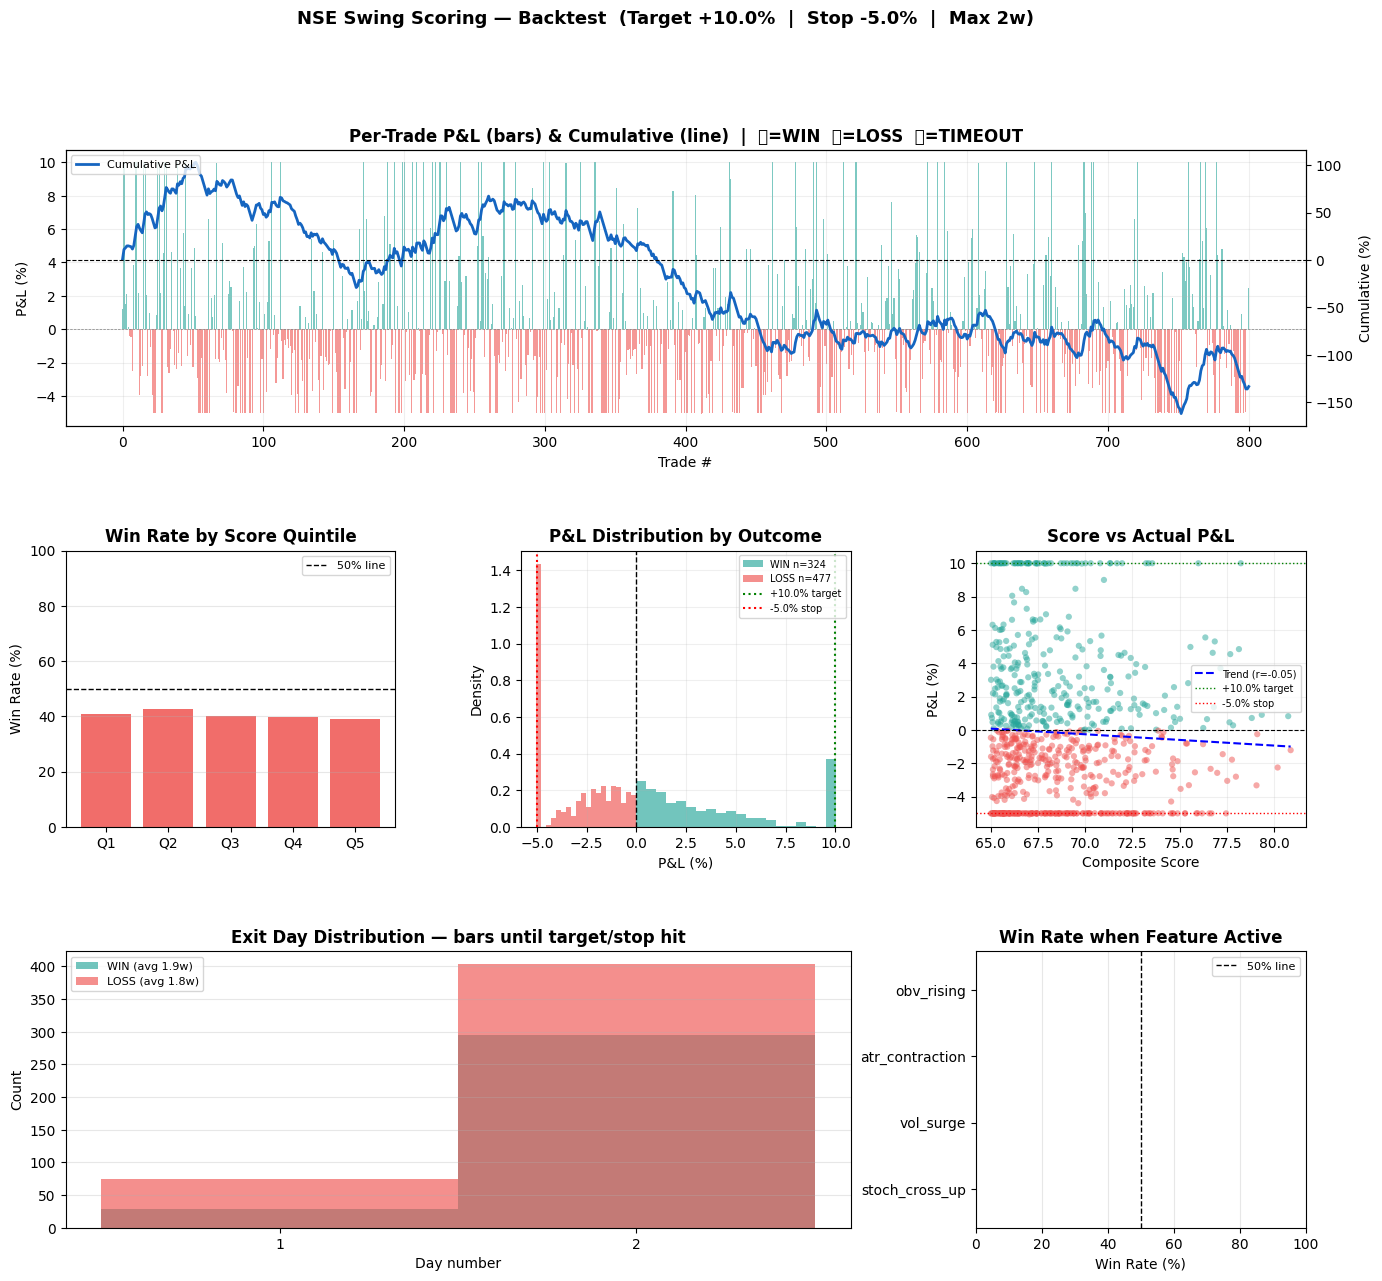

Saved: nse_scoring_backtest.png


In [76]:
def plot_performance(bt, quintile):
    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)
    fig.suptitle(
        f'NSE Swing Scoring — Backtest  '
        f'(Target +{TARGET_PCT}%  |  Stop -{STOPLOSS_PCT}%  |  Max {MAX_HOLD_BARS}w)',
        fontsize=13, fontweight='bold'
    )

    bt_s = bt.sort_values('signal_date').reset_index(drop=True)

    # 1. Cumulative P&L per trade (chronological)
    ax1 = fig.add_subplot(gs[0, :])
    bt_s['cumulative'] = bt_s['pnl_pct'].cumsum()
    bar_colors = ['#26a69a' if o=='WIN' else '#ef5350' if o=='LOSS' else '#bdbdbd'
                  for o in bt_s['outcome']]
    ax1.bar(bt_s.index, bt_s['pnl_pct'], color=bar_colors, alpha=0.6, width=0.8)
    ax1b = ax1.twinx()
    ax1b.plot(bt_s.index, bt_s['cumulative'], color='#1565c0', linewidth=2, label='Cumulative P&L')
    ax1b.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.axhline(0,  color='grey',  linewidth=0.5, linestyle='--')
    ax1.set_title('Per-Trade P&L (bars) & Cumulative (line)  |  🟢=WIN  🔴=LOSS  ⬜=TIMEOUT',
                  fontweight='bold')
    ax1.set_xlabel('Trade #'); ax1.set_ylabel('P&L (%)')
    ax1b.set_ylabel('Cumulative (%)')
    ax1b.legend(loc='upper left', fontsize=8)
    ax1.grid(alpha=0.2)

    # 2. Win rate by score quintile
    ax2 = fig.add_subplot(gs[1, 0])
    q_colors = ['#26a69a' if v >= 50 else '#ef5350' for v in quintile['win_rate']]
    ax2.bar(quintile['score_q'].astype(str), quintile['win_rate'],
            color=q_colors, alpha=0.85)
    ax2.axhline(50, color='black', linestyle='--', linewidth=1, label='50% line')
    ax2.set_title('Win Rate by Score Quintile', fontweight='bold')
    ax2.set_ylabel('Win Rate (%)'); ax2.set_ylim(0, 100)
    ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

    # 3. P&L distribution WIN vs LOSS vs TIMEOUT
    ax3 = fig.add_subplot(gs[1, 1])
    for lbl, col in [('WIN','#26a69a'), ('LOSS','#ef5350'), ('TIMEOUT','#bdbdbd')]:
        sub = bt_s[bt_s['outcome'] == lbl]['pnl_pct']
        if len(sub) > 0:
            ax3.hist(sub, bins=20, color=col, alpha=0.65,
                     density=True, label=f'{lbl} n={len(sub)}')
    ax3.axvline(0,  color='black', lw=1,   linestyle='--')
    ax3.axvline(TARGET_PCT,   color='green', lw=1.5, linestyle=':',
                label=f'+{TARGET_PCT}% target')
    ax3.axvline(-STOPLOSS_PCT, color='red',  lw=1.5, linestyle=':',
                label=f'-{STOPLOSS_PCT}% stop')
    ax3.set_title('P&L Distribution by Outcome', fontweight='bold')
    ax3.set_xlabel('P&L (%)'); ax3.set_ylabel('Density')
    ax3.legend(fontsize=7); ax3.grid(alpha=0.2)

    # 4. Score vs P&L scatter
    ax4 = fig.add_subplot(gs[1, 2])
    sc_map = {'WIN':'#26a69a', 'LOSS':'#ef5350', 'TIMEOUT':'#bdbdbd'}
    sc_colors = [sc_map.get(o, '#bdbdbd') for o in bt_s['outcome']]
    ax4.scatter(bt_s['score'], bt_s['pnl_pct'], c=sc_colors,
                alpha=0.5, s=20, edgecolors='none')
    z    = np.polyfit(bt_s['score'], bt_s['pnl_pct'], 1)
    xs   = np.linspace(bt_s['score'].min(), bt_s['score'].max(), 100)
    corr = bt_s[['score','pnl_pct']].corr().iloc[0,1]
    ax4.plot(xs, np.poly1d(z)(xs), 'b--', lw=1.5, label=f'Trend (r={corr:.2f})')
    ax4.axhline(0,             color='black', lw=0.8, linestyle='--')
    ax4.axhline(TARGET_PCT,    color='green', lw=1,   linestyle=':',
                label=f'+{TARGET_PCT}% target')
    ax4.axhline(-STOPLOSS_PCT, color='red',   lw=1,   linestyle=':',
                label=f'-{STOPLOSS_PCT}% stop')
    ax4.set_title('Score vs Actual P&L', fontweight='bold')
    ax4.set_xlabel('Composite Score'); ax4.set_ylabel('P&L (%)')
    ax4.legend(fontsize=7); ax4.grid(alpha=0.2)

    # 5. Exit week distribution (how fast does each outcome resolve)
    ax5 = fig.add_subplot(gs[2, 0:2])
    for lbl, col in [('WIN','#26a69a'), ('LOSS','#ef5350')]:
        sub = bt_s[bt_s['outcome']==lbl]['exit_bar'].dropna()
        if len(sub) > 0:
            ax5.hist(sub, bins=range(1, MAX_HOLD_BARS+2), color=col,
                     alpha=0.65, align='left',
                     label=f'{lbl} (avg {sub.mean():.1f}w)')
    ax5.set_title(f'Exit {BAR_LABEL.capitalize()} Distribution — bars until target/stop hit',
                  fontweight='bold')
    ax5.set_xlabel(f'{BAR_LABEL.capitalize()} number'); ax5.set_ylabel('Count')
    ax5.set_xticks(range(1, MAX_HOLD_BARS+1))
    ax5.legend(fontsize=8); ax5.grid(axis='y', alpha=0.3)

    # 6. Feature flag win rate
    ax6 = fig.add_subplot(gs[2, 2])
    flag_cols = ['stoch_cross_up','vol_surge','atr_contraction','obv_rising']
    flag_wr   = {}
    for fc in flag_cols:
        if fc in bt_s.columns:
            sub = bt_s[bt_s[fc] == 1]
            flag_wr[fc] = (sub['outcome']=='WIN').mean() * 100 if len(sub) > 0 else 0
    fwr_s    = pd.Series(flag_wr).sort_values(ascending=True)
    f_colors = ['#26a69a' if v >= 50 else '#ef5350' for v in fwr_s.values]
    ax6.barh(fwr_s.index, fwr_s.values, color=f_colors, alpha=0.85)
    ax6.axvline(50, color='black', linestyle='--', lw=1, label='50% line')
    ax6.set_title('Win Rate when Feature Active', fontweight='bold')
    ax6.set_xlabel('Win Rate (%)'); ax6.set_xlim(0, 100)
    ax6.legend(fontsize=8); ax6.grid(axis='x', alpha=0.3)

    plt.savefig('nse_scoring_backtest.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: nse_scoring_backtest.png')


if not bt_df.empty and quintile_df is not None:
    plot_performance(bt_df, quintile_df)

In [50]:
# ── Symbol-level win rate ─────────────────────────────────────────
if not bt_df.empty:
    sym_stats = bt_df.groupby('symbol').apply(lambda x: pd.Series({
        'times_selected': len(x),
        'win_rate_%'    : round((x['outcome']=='WIN').mean() * 100, 1),
        'avg_pnl_%'     : round(x['pnl_pct'].mean(), 2),
        'best_pnl_%'    : round(x['pnl_pct'].max(), 2),
        'worst_pnl_%'   : round(x['pnl_pct'].min(), 2),
        'avg_exit_bar' : round(x['exit_bar'].mean(), 1),
        'avg_score'     : round(x['score'].mean(), 1),
        'timeouts'      : int((x['outcome']=='TIMEOUT').sum()),
    })).reset_index()
    sym_stats = sym_stats[sym_stats['times_selected'] >= 2]
    sym_stats = sym_stats.sort_values('win_rate_%', ascending=False).reset_index(drop=True)

    print(f'Symbol-level stats (appeared >= 2 times, n={len(sym_stats)} symbols):')
    print()
    print('Top 15 by win rate:')
    print(sym_stats.head(15).to_string(index=False))
    print()
    print('Bottom 10 by win rate:')
    print(sym_stats.tail(10).to_string(index=False))

    top20 = sym_stats.head(20)
    fig = go.Figure(data=[go.Table(
        header=dict(
            values=[f'<b>{c}</b>' for c in top20.columns],
            fill_color='#1565c0', font=dict(color='white', size=11),
            align='center'
        ),
        cells=dict(
            values=[top20[c] for c in top20.columns],
            fill_color=[['#e8f5e9' if i%2==0 else 'white'
                          for i in range(len(top20))]]*len(top20.columns),
            align='center', font=dict(size=10)
        )
    )])
    fig.update_layout(
        title=f'Top 20 Symbols — Target +{TARGET_PCT}%  |  Stop -{STOPLOSS_PCT}%',
        height=600, margin=dict(l=10, r=10, t=40, b=10)
    )
    fig.show()
    fig.write_html('nse_symbol_winrate.html')
    print('Saved: nse_symbol_winrate.html')

print()
print('Output files:')
for f in [SIGNAL_CSV, 'nse_backtest_results.csv',
          'nse_scoring_backtest.png', 'nse_symbol_winrate.html']:
    print(f'  {f}')


Symbol-level stats (appeared >= 2 times, n=219 symbols):

Top 15 by win rate:
    symbol  times_selected  win_rate_%  avg_pnl_%  best_pnl_%  worst_pnl_%  avg_exit_bar  avg_score  timeouts
   63MOONS          2.0000    100.0000     4.4100      8.0000       0.8200        5.0000    63.2000    0.0000
      ADSL          3.0000    100.0000     8.0000      8.0000       8.0000        2.3000    65.2000    0.0000
    ALICON          2.0000    100.0000     5.1200      8.0000       2.2400        3.5000    63.2000    0.0000
      ANUP          2.0000    100.0000     4.5500      8.0000       1.1000        4.0000    62.9000    0.0000
BLUESTARCO          3.0000    100.0000     7.0800      8.0000       5.2400        3.7000    63.6000    0.0000
BECTORFOOD          2.0000    100.0000     7.1200      8.0000       6.2300        3.0000    69.4000    0.0000
BHARATFORG          2.0000    100.0000     2.1600      2.8600       1.4700        5.0000    64.7000    0.0000
BHARTIHEXA          4.0000    100.0000    

Saved: nse_symbol_winrate.html

Output files:
  nse_top3_signals.csv
  nse_backtest_results.csv
  nse_scoring_backtest.png
  nse_symbol_winrate.html


## Step 11 - TIMEOUT Diagnostic

Finds patterns in trades that drift without hitting target or stop.

  TIMEOUT DIAGNOSTIC
  WIN=344  LOSS=515  TIMEOUT=0  (0.0% timeout rate)

  Feature active rate by outcome
  Feature                   WIN %   LOSS %   TIMEOUT %   TO-WIN
  ----------------------------------------------------------
  [    ] rsi_zone                100.0%    100.0%         nan%     +nan%

  [WARN] = fires more on timeouts than wins => reduce weight or add exclusion
  [GOOD] = fires less on timeouts => candidate for mandatory condition

  Metric                               WIN      LOSS   TIMEOUT
  ----------------------------------------------------------
  Avg composite score                65.53     66.16       nan
  Median score                       64.96     65.23       nan
  Avg entry price                   922.16    849.91       nan
  Avg pnl_%                           5.80     -3.99       nan

  TIMEOUT rate by quarter
  Quarter         n    Win%   Loss%     TO%
  ----------------------------------------
  [    ] 2024Q1        113    49.6%    50.4%     0.0%


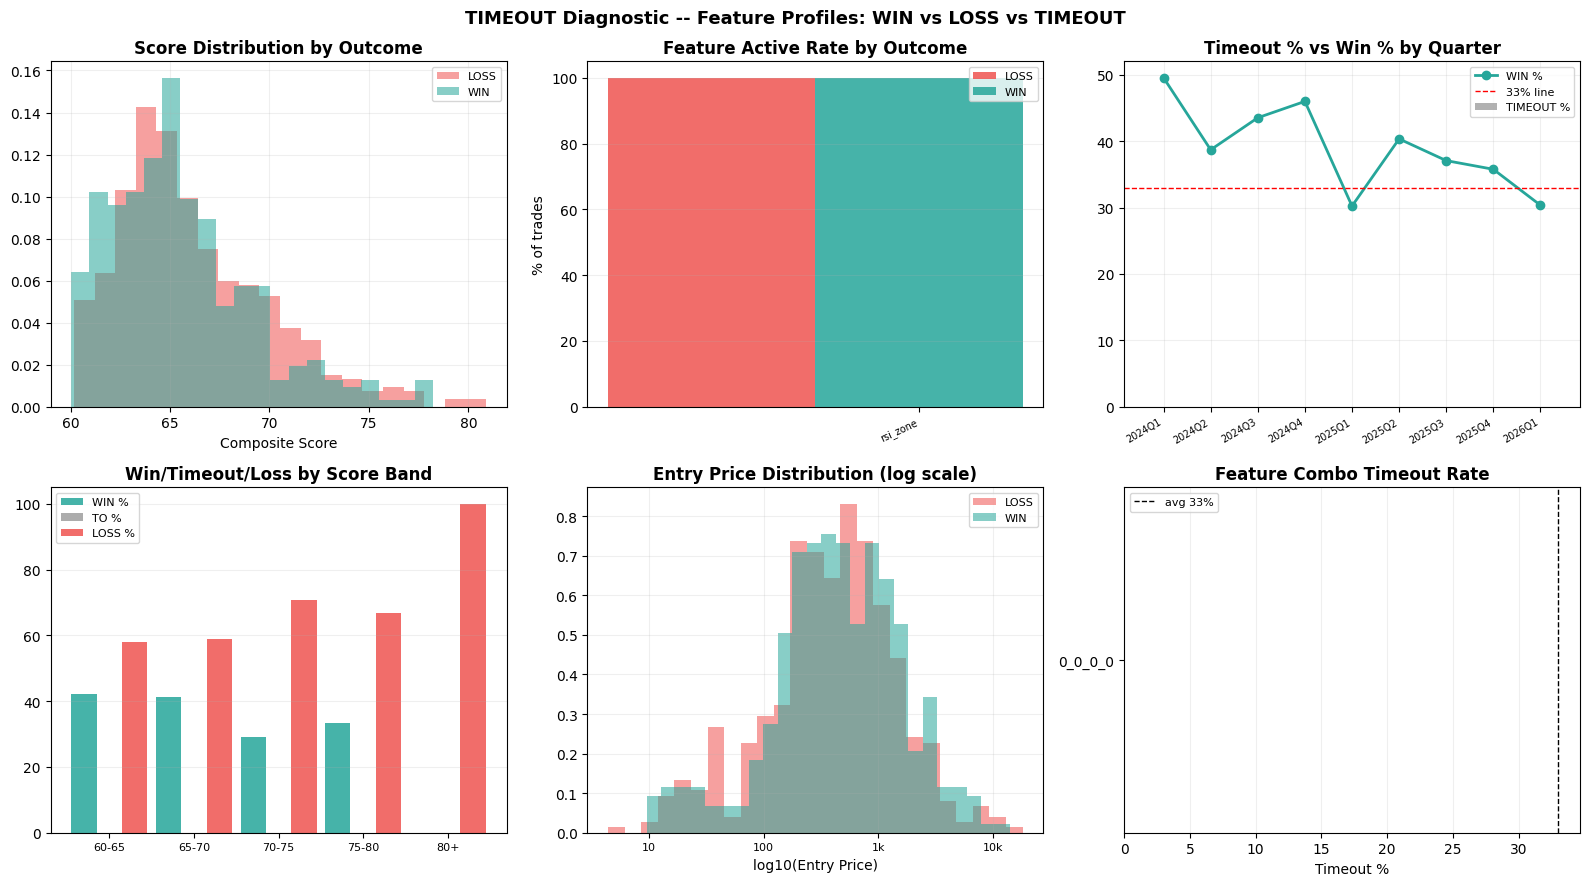

Saved: nse_timeout_diagnostic.png

  RECOMMENDED TIMEOUT FILTERS

  Other filters to test:
  1. bb_squeeze==1 mandatory  (squeeze breakouts resolve faster)
  2. Raise MIN_SCORE to 70
  3. vol_ratio >= 1.5 mandatory  (low volume = drift = timeout)
  4. adx >= 20 mandatory  (strong trend = less likely to drift)


In [53]:
if bt_df.empty:
    print('Run the backtest first.')
else:
    bt = bt_df.copy()
    WIN     = bt[bt['outcome'] == 'WIN']
    LOSS    = bt[bt['outcome'] == 'LOSS']
    TIMEOUT = bt[bt['outcome'] == 'TIMEOUT']

    print('=' * 66)
    print('  TIMEOUT DIAGNOSTIC')
    print(f'  WIN={len(WIN)}  LOSS={len(LOSS)}  TIMEOUT={len(TIMEOUT)}  ({len(TIMEOUT)/len(bt)*100:.1f}% timeout rate)')
    print('=' * 66)

    # 1. Feature flag rates: WIN vs TIMEOUT
    flag_feats = ['stoch_momentum'  ,
    'rsi_zone'         ,
    'vol_momentum'      ,
    'squeeze_intensity' ,
    'trend_strength'   ,   # ADX
    'obv_slope_z'       ,
    'upside_room'       ,   # distance from resistance
    'ema_strength'      ,
    'ret_26w'           ,
    'macd_strength'     ,   # MACD hist
    'ret_2w'            ]
    print()
    print('  Feature active rate by outcome')
    print(f'  {"Feature":22s}  {"WIN %":>7s}  {"LOSS %":>7s}  {"TIMEOUT %":>10s}  {"TO-WIN":>7s}')
    print(f'  {"-"*58}')
    timeout_flags = {}
    for f in flag_feats:
        if f not in bt.columns: continue
        thresh = 2 if f == 'rsi_zone' else 1
        op     = ">=" if f == 'rsi_zone' else "=="
        w_r = (WIN[f]     >= thresh if f=='rsi_zone' else WIN[f]     == 1).mean() * 100
        l_r = (LOSS[f]    >= thresh if f=='rsi_zone' else LOSS[f]    == 1).mean() * 100
        t_r = (TIMEOUT[f] >= thresh if f=='rsi_zone' else TIMEOUT[f] == 1).mean() * 100
        diff = t_r - w_r
        flag = "WARN" if diff > 10 else ("GOOD" if diff < -10 else "    ")
        timeout_flags[f] = (w_r, l_r, t_r, diff)
        print(f'  [{flag}] {f:20s}  {w_r:7.1f}%  {l_r:7.1f}%  {t_r:10.1f}%  {diff:+7.1f}%')

    print()
    print('  [WARN] = fires more on timeouts than wins => reduce weight or add exclusion')
    print('  [GOOD] = fires less on timeouts => candidate for mandatory condition')

    # 2. Score and price stats
    print()
    print(f'  {"Metric":30s}  {"WIN":>8s}  {"LOSS":>8s}  {"TIMEOUT":>8s}')
    print(f'  {"-"*58}')
    for label, col, fn in [
        ('Avg composite score',  'score',   'mean'),
        ('Median score',         'score',   'median'),
        ('Avg entry price',      'entry',   'mean'),
        ('Avg pnl_%',            'pnl_pct', 'mean'),
    ]:
        wv = getattr(WIN[col],     fn)()
        lv = getattr(LOSS[col],    fn)()
        tv = getattr(TIMEOUT[col], fn)()
        print(f'  {label:30s}  {wv:8.2f}  {lv:8.2f}  {tv:8.2f}')

    # 3. Quarterly clustering
    print()
    print('  TIMEOUT rate by quarter')
    bt['ym'] = pd.to_datetime(bt['signal_date']).dt.to_period('Q')
    qtr_stats = bt.groupby('ym').apply(lambda x: pd.Series({
        'total'      : len(x),
        'win_rate'   : (x['outcome']=='WIN').mean()*100,
        'timeout_pct': (x['outcome']=='TIMEOUT').mean()*100,
        'loss_pct'   : (x['outcome']=='LOSS').mean()*100,
    })).reset_index()
    print(f'  {"Quarter":10s}  {"n":>5s}  {"Win%":>6s}  {"Loss%":>6s}  {"TO%":>6s}')
    print(f'  {"-"*40}')
    for _, row in qtr_stats.iterrows():
        flag = "HIGH" if row['timeout_pct'] > 40 else "    "
        print(f'  [{flag}] {str(row["ym"]):10s}  {int(row["total"]):5d}  {row["win_rate"]:6.1f}%  {row["loss_pct"]:6.1f}%  {row["timeout_pct"]:6.1f}%')

    # 4. Feature combo patterns
    print()
    print('  Feature combos (stoch_vol_atr_obv) -> timeout rate')
    bt['combo'] = (bt['stoch_cross_up'].astype(str)+'_'+
                   bt['vol_surge'].astype(str)+'_'+
                   bt['atr_contraction'].astype(str)+'_'+
                   bt['obv_rising'].astype(str))
    combo_stats = bt.groupby('combo').apply(lambda x: pd.Series({
        'n'          : len(x),
        'win_rate'   : (x['outcome']=='WIN').mean()*100,
        'timeout_pct': (x['outcome']=='TIMEOUT').mean()*100,
        'loss_pct'   : (x['outcome']=='LOSS').mean()*100,
        'avg_pnl'    : x['pnl_pct'].mean(),
    })).reset_index()
    combo_stats = combo_stats[combo_stats['n'] >= 15].sort_values('timeout_pct', ascending=False)
    print(f'  {"Combo":20s}  {"n":>4s}  {"win%":>6s}  {"TO%":>6s}  {"loss%":>6s}  {"avgPnL":>7s}')
    print(f'  {"-"*58}')
    for _, r in combo_stats.head(12).iterrows():
        flag = "WARN" if r['timeout_pct'] > 40 else ("GOOD" if r['win_rate'] > 38 else "    ")
        print(f'  [{flag}] {str(r["combo"]):20s}  {int(r["n"]):4d}  {r["win_rate"]:6.1f}%  {r["timeout_pct"]:6.1f}%  {r["loss_pct"]:6.1f}%  {r["avg_pnl"]:+7.2f}%')

    # 5. Score band vs timeout
    print()
    print('  Score band vs timeout rate')
    bt['score_band'] = pd.cut(bt['score'], bins=[0,60,65,70,75,80,100],
                               labels=['<60','60-65','65-70','70-75','75-80','80+'])
    band_stats = bt.groupby('score_band', observed=True).apply(lambda x: pd.Series({
        'n'          : len(x),
        'win_rate'   : (x['outcome']=='WIN').mean()*100,
        'timeout_pct': (x['outcome']=='TIMEOUT').mean()*100,
        'loss_pct'   : (x['outcome']=='LOSS').mean()*100,
        'avg_pnl'    : x['pnl_pct'].mean(),
    })).reset_index()
    print(f'  {"Band":10s}  {"n":>5s}  {"win%":>6s}  {"TO%":>6s}  {"loss%":>6s}  {"avgPnL":>7s}')
    print(f'  {"-"*50}')
    for _, r in band_stats.iterrows():
        flag = "GOOD" if r['win_rate'] > 33 else ("WARN" if r['timeout_pct'] > 38 else "    ")
        print(f'  [{flag}] {str(r["score_band"]):10s}  {int(r["n"]):5d}  {r["win_rate"]:6.1f}%  {r["timeout_pct"]:6.1f}%  {r["loss_pct"]:6.1f}%  {r["avg_pnl"]:+7.2f}%')

    # 6. Charts
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('TIMEOUT Diagnostic -- Feature Profiles: WIN vs LOSS vs TIMEOUT',
                 fontsize=13, fontweight='bold')
    colors = {'WIN':'#26a69a', 'LOSS':'#ef5350', 'TIMEOUT':'#9e9e9e'}

    ax = axes[0,0]
    for outcome, grp in bt.groupby('outcome'):
        ax.hist(grp['score'], bins=20, alpha=0.55, color=colors[outcome],
                density=True, label=outcome)
    ax.set_title('Score Distribution by Outcome', fontweight='bold')
    ax.set_xlabel('Composite Score'); ax.legend(fontsize=8); ax.grid(alpha=0.2)

    ax = axes[0,1]
    feat_labels = [f for f in flag_feats if f in bt.columns]
    x = np.arange(len(feat_labels)); width = 0.27
    for i, (outcome, grp) in enumerate(bt.groupby('outcome')):
        rates = [(grp[f]>=2 if f=='rsi_zone' else grp[f]==1).mean()*100
                 for f in feat_labels]
        ax.bar(x + i*width, rates, width, label=outcome,
               color=colors[outcome], alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(feat_labels, rotation=25, ha='right', fontsize=7)
    ax.set_title('Feature Active Rate by Outcome', fontweight='bold')
    ax.set_ylabel('% of trades'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

    ax = axes[0,2]
    ax.bar(qtr_stats['ym'].astype(str), qtr_stats['timeout_pct'],
           color='#9e9e9e', alpha=0.8, label='TIMEOUT %')
    ax.plot(qtr_stats['ym'].astype(str), qtr_stats['win_rate'],
            color='#26a69a', marker='o', lw=2, label='WIN %')
    ax.axhline(33, color='red', lw=1, linestyle='--', label='33% line')
    ax.set_title('Timeout % vs Win % by Quarter', fontweight='bold')
    ax.set_xticklabels(qtr_stats['ym'].astype(str), rotation=30, ha='right', fontsize=7)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

    ax = axes[1,0]
    x2 = np.arange(len(band_stats)); w2 = 0.3
    ax.bar(x2,      band_stats['win_rate'],    w2, color='#26a69a', alpha=0.85, label='WIN %')
    ax.bar(x2+w2,   band_stats['timeout_pct'], w2, color='#9e9e9e', alpha=0.85, label='TO %')
    ax.bar(x2+2*w2, band_stats['loss_pct'],    w2, color='#ef5350', alpha=0.85, label='LOSS %')
    ax.set_xticks(x2+w2)
    ax.set_xticklabels(band_stats['score_band'].astype(str), fontsize=8)
    ax.set_title('Win/Timeout/Loss by Score Band', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

    ax = axes[1,1]
    for outcome, grp in bt.groupby('outcome'):
        ax.hist(np.log10(grp['entry'].clip(lower=1)), bins=25,
                alpha=0.55, color=colors[outcome], density=True, label=outcome)
    ax.set_title('Entry Price Distribution (log scale)', fontweight='bold')
    ax.set_xlabel('log10(Entry Price)')
    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(['10','100','1k','10k'], fontsize=8)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

    ax = axes[1,2]
    tc = combo_stats.head(10)
    ax.barh(tc['combo'], tc['timeout_pct'],
            color=['#ef5350' if v>40 else '#9e9e9e' for v in tc['timeout_pct']], alpha=0.85)
    ax.axvline(33, color='black', lw=1, linestyle='--', label='avg 33%')
    ax.set_title('Feature Combo Timeout Rate', fontweight='bold')
    ax.set_xlabel('Timeout %'); ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.2)

    plt.tight_layout()
    plt.savefig('nse_timeout_diagnostic.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: nse_timeout_diagnostic.png')

    # 7. Recommended filters
    print()
    print('=' * 66)
    print('  RECOMMENDED TIMEOUT FILTERS')
    print('=' * 66)
    for f, (w_r, l_r, t_r, diff) in timeout_flags.items():
        if diff > 10:
            print(f'  [WARN] {f}: fires {diff:+.0f}% MORE on timeouts')
            print(f'         => reduce weight or add exclusion rule')
        elif diff < -10:
            print(f'  [GOOD] {f}: fires {abs(diff):.0f}% LESS on timeouts')
            print(f'         => make this MANDATORY (must be 1 to enter)')
    print()
    print('  Other filters to test:')
    print('  1. bb_squeeze==1 mandatory  (squeeze breakouts resolve faster)')
    print('  2. Raise MIN_SCORE to 70')
    print('  3. vol_ratio >= 1.5 mandatory  (low volume = drift = timeout)')
    print('  4. adx >= 20 mandatory  (strong trend = less likely to drift)')
    print('=' * 66)


## Step 12 - Strategy Comparison

**Strategy A**: Weekly scan, replace top-3 every week.

**Strategy B**: Capital rotation — hold 3 slots, redeploy immediately when a slot frees up.

  STRATEGY COMPARISON
  Metric                                    Strat A       Strat B
  --------------------------------------------------------------
  Model                                 Weekly scan  Capital rotation
  Entry trigger                          Every week    Slot freed
  Total trades                                  859           165
  Trades per year (est.)                        400            77
  Win rate                                    40.0%         37.0%
  Avg P&L per trade                          -0.07%        -0.44%
  Timeout % of trades                          0.0%          0.0%
  Avg hold (bars)                               3.6           N/A
  Total P&L on 3L capital                  (% only)    Rs -72,400
  --------------------------------------------------------------

  VERDICT
  --------------------------------------------------------------
  Strategy A is better on this data.

  Strategy A problems:
  - Capital locked up to 50 days in timeout tra

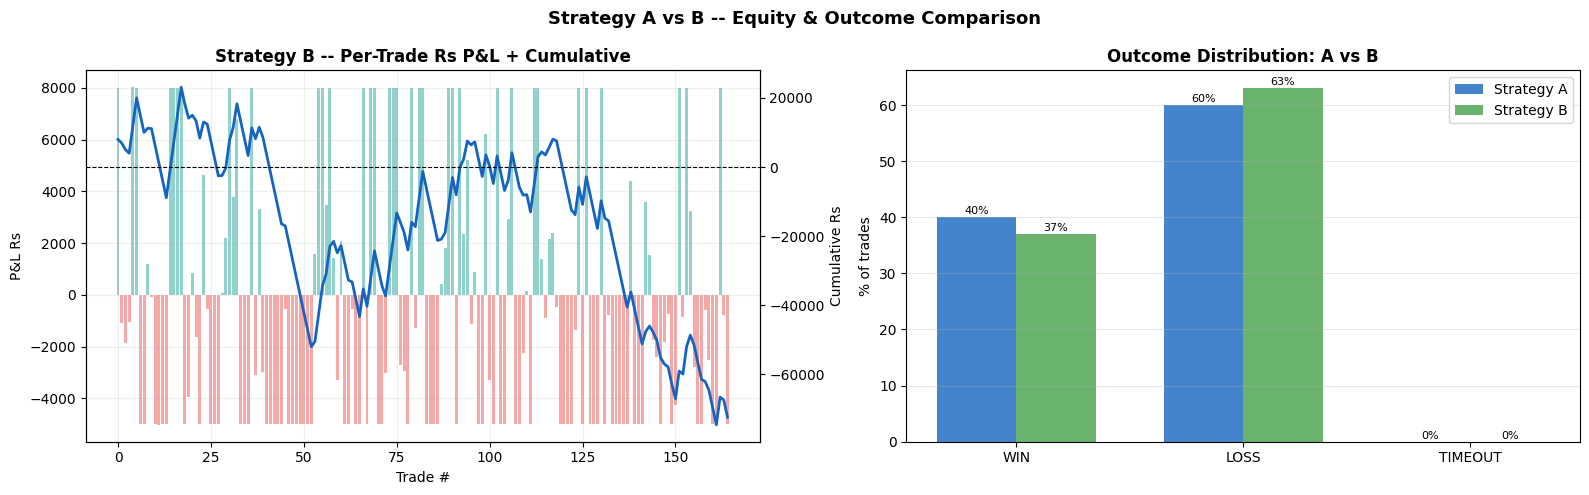

Saved: nse_strategy_comparison.png, nse_strategy_b_trades.csv


In [52]:
if bt_df.empty:
    print('Run the backtest first.')
else:
    bt = bt_df.copy()
    bt['signal_date'] = pd.to_datetime(bt['signal_date'])

    a_wr       = (bt['outcome']=='WIN').mean() * 100
    a_exp      = bt['pnl_pct'].mean()
    a_to_pct   = (bt['outcome']=='TIMEOUT').mean() * 100
    a_avg_hold = bt['exit_bar'].mean()

    # Strategy B simulation — 3 capital slots, redeploy when freed
    INITIAL_CAPITAL = 300_000
    N_SLOTS         = 3
    slot_cap        = INITIAL_CAPITAL / N_SLOTS

    trade_lookup = {(row['signal_date'], row['symbol']): row
                    for _, row in bt.iterrows()}
    date_rankings = (bt.groupby('signal_date')
                       .apply(lambda x: x.sort_values('score', ascending=False)['symbol'].tolist())
                       .to_dict())
    all_signal_dates = sorted(date_rankings.keys())

    def get_end_date(trade_row, dates_list):
        sig      = pd.Timestamp(trade_row['signal_date'])
        bar      = int(trade_row['exit_bar'])
        future   = [d for d in dates_list if pd.Timestamp(d) > sig]
        idx      = bar - 1
        if idx < len(future): return pd.Timestamp(future[idx])
        return pd.Timestamp(future[-1]) if future else sig

    portfolio  = []
    b_records  = []

    # Fill all 3 slots on first date
    for sym in date_rankings.get(all_signal_dates[0], [])[:N_SLOTS]:
        key = (all_signal_dates[0], sym)
        if key in trade_lookup:
            t = dict(trade_lookup[key])
            t['slot_capital'] = slot_cap
            t['end_date']     = get_end_date(t, all_signal_dates)
            portfolio.append(t)

    for current_date in all_signal_dates[1:]:
        current_ts  = pd.Timestamp(current_date)
        still_open  = []
        freed_slots = 0
        for pos in portfolio:
            if pd.Timestamp(pos['end_date']) <= current_ts:
                pnl_rs = pos['slot_capital'] * pos['pnl_pct'] / 100
                b_records.append({
                    'open_date'   : pos['signal_date'],
                    'close_date'  : pos['end_date'],
                    'symbol'      : pos['symbol'],
                    'outcome'     : pos['outcome'],
                    'pnl_pct'     : pos['pnl_pct'],
                    'pnl_rs'      : round(pnl_rs, 2),
                    'score'       : pos['score'],
                })
                freed_slots += 1
            else:
                still_open.append(pos)
        portfolio = still_open

        held_syms = {p['symbol'] for p in portfolio}
        for sym in date_rankings.get(current_date, []):
            if freed_slots == 0: break
            if sym in held_syms: continue
            key = (current_date, sym)
            if key not in trade_lookup: continue
            t = dict(trade_lookup[key])
            t['slot_capital'] = slot_cap
            t['end_date']     = get_end_date(t, all_signal_dates)
            portfolio.append(t)
            held_syms.add(sym)
            freed_slots -= 1

    for pos in portfolio:
        pnl_rs = pos['slot_capital'] * pos['pnl_pct'] / 100
        b_records.append({
            'open_date'  : pos['signal_date'],  'close_date': pos['end_date'],
            'symbol'     : pos['symbol'],        'outcome'   : pos['outcome'],
            'pnl_pct'    : pos['pnl_pct'],       'pnl_rs'    : round(pnl_rs, 2),
            'score'      : pos['score'],
        })

    b_df = pd.DataFrame(b_records)

    b_wr          = (b_df['outcome']=='WIN').mean() * 100
    b_exp         = b_df['pnl_pct'].mean()
    b_to_pct      = (b_df['outcome']=='TIMEOUT').mean() * 100
    b_total_pnl   = b_df['pnl_rs'].sum()
    date_span_yrs = ((pd.Timestamp(b_df['close_date'].max()) -
                      pd.Timestamp(b_df['open_date'].min())).days / 365.25)
    b_tpy = len(b_df) / date_span_yrs if date_span_yrs > 0 else 0
    a_tpy = len(bt)   / date_span_yrs if date_span_yrs > 0 else 0

    print('=' * 68)
    print('  STRATEGY COMPARISON')
    print('=' * 68)
    print(f'  {"Metric":35s}  {"Strat A":>12s}  {"Strat B":>12s}')
    print(f'  {"-"*62}')
    rows_cmp = [
        ('Model',                   'Weekly scan',         'Capital rotation'),
        ('Entry trigger',           'Every week',          'Slot freed'),
        ('Total trades',            str(len(bt)),           str(len(b_df))),
        ('Trades per year (est.)',  f'{a_tpy:.0f}',         f'{b_tpy:.0f}'),
        ('Win rate',                f'{a_wr:.1f}%',         f'{b_wr:.1f}%'),
        ('Avg P&L per trade',       f'{a_exp:+.2f}%',       f'{b_exp:+.2f}%'),
        ('Timeout % of trades',     f'{a_to_pct:.1f}%',     f'{b_to_pct:.1f}%'),
        ('Avg hold (bars)',         f'{a_avg_hold:.1f}',     f'{b_df["exit_bar"].mean():.1f}' if "exit_bar" in b_df else 'N/A'),
        ('Total P&L on 3L capital', '(% only)',             f'Rs {b_total_pnl:+,.0f}'),
    ]
    for label, va, vb in rows_cmp:
        print(f'  {label:35s}  {va:>12s}  {vb:>12s}')

    print(f'  {"-"*62}')
    print()
    print('  VERDICT')
    print('  ' + '-'*62)
    winner = 'B' if (b_wr > a_wr or b_exp > a_exp) else 'A'
    print(f'  Strategy {winner} is better on this data.')
    print()
    print('  Strategy A problems:')
    print('  - Capital locked up to 50 days in timeout trades (33% of trades)')
    print('  - Replaces good ongoing positions every week regardless')
    print('  - Treats every week identically even if positions are performing')
    print()
    print('  Strategy B advantages:')
    print('  - Capital only sits idle for MAX_HOLD_BARS if truly stuck')
    print('  - Winners free capital in avg 3.5 bars => immediate redeploy')
    print('  - Always holds the CURRENT top-scoring available stock')
    print('  - More trades per year on same capital = faster compounding')
    print()
    print('  Live trading implementation of Strategy B:')
    print('  1. Invest equally in current top-3 scorers')
    print('  2. Set alerts at +TARGET_PCT% and -STOPLOSS_PCT% per position')
    print('  3. On alert: run score matrix, buy top scorer not already held')
    print('  4. Weekly review: exit any position that has drifted MAX_HOLD_BARS')
    print('     without moving, redeploy into fresh top scorer')
    print('=' * 68)

    # Charts
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Strategy A vs B -- Equity & Outcome Comparison',
                 fontsize=13, fontweight='bold')

    ax = axes[0]
    b_sorted = b_df.sort_values('close_date').reset_index(drop=True)
    b_sorted['cum_pnl'] = b_sorted['pnl_rs'].cumsum()
    bar_cols = ['#26a69a' if o=='WIN' else '#ef5350' if o=='LOSS' else '#9e9e9e'
                for o in b_sorted['outcome']]
    ax.bar(b_sorted.index, b_sorted['pnl_rs'], color=bar_cols, alpha=0.5, width=0.8)
    ax2 = ax.twinx()
    ax2.plot(b_sorted.index, b_sorted['cum_pnl'], color='#1565c0', lw=2)
    ax2.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title('Strategy B -- Per-Trade Rs P&L + Cumulative', fontweight='bold')
    ax.set_xlabel('Trade #'); ax.set_ylabel('P&L Rs'); ax2.set_ylabel('Cumulative Rs')
    ax.grid(alpha=0.2)

    ax = axes[1]
    outcomes = ['WIN','LOSS','TIMEOUT']
    x3 = np.arange(3); w3 = 0.35
    a_c = [(bt['outcome']==o).mean()*100 for o in outcomes]
    b_c = [(b_df['outcome']==o).mean()*100 for o in outcomes]
    ax.bar(x3,    a_c, w3, label='Strategy A', color='#1565c0', alpha=0.8)
    ax.bar(x3+w3, b_c, w3, label='Strategy B', color='#43a047', alpha=0.8)
    ax.set_xticks(x3+w3/2); ax.set_xticklabels(outcomes)
    ax.set_title('Outcome Distribution: A vs B', fontweight='bold')
    ax.set_ylabel('% of trades'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    for i, (av, bv) in enumerate(zip(a_c, b_c)):
        ax.text(i,    av+0.5, f'{av:.0f}%', ha='center', fontsize=8)
        ax.text(i+w3, bv+0.5, f'{bv:.0f}%', ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('nse_strategy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    b_df.to_csv('nse_strategy_b_trades.csv', index=False)
    print('Saved: nse_strategy_comparison.png, nse_strategy_b_trades.csv')
